In [1]:
# Step 1: Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK data download
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kashi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kashi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kashi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


✅ All libraries imported successfully!


In [2]:
# Step 2: Synthetic Tour Enquiry Dataset Banao
np.random.seed(42)

enquiries = [
    "I need urgent booking for Goa trip this weekend, please help immediately!",
    "Looking for a relaxing beach vacation in Kerala next month",
    "URGENT! Need to book honeymoon package for Maldives ASAP!",
    "Interested in exploring hill stations in Himachal Pradesh",
    "Please confirm my booking immediately, its very urgent!",
    "Casual trip to Rajasthan with family, no rush",
    "Need adventure sports package in Rishikesh urgently",
    "Planning a leisure trip to Andaman islands next year",
    "Emergency booking needed for corporate trip to Delhi",
    "Thinking about visiting Kerala backwaters someday",
    "Very urgent! Need to book flight and hotel for tomorrow",
    "Would love to explore the temples of Tamil Nadu",
    "ASAP booking needed for business travel to Mumbai",
    "Planning a budget trip to Northeast India",
    "Critical booking needed for medical tourism in Chennai",
]

texts = enquiries * 14
texts = texts[:200]
labels = ['urgent' if any(word in t.lower() for word in 
          ['urgent', 'asap', 'immediately', 'emergency', 'critical']) 
          else 'normal' for t in texts]

df = pd.DataFrame({'text': texts, 'label': labels})

print("✅ Dataset created!")
print(df['label'].value_counts())
df.head()

✅ Dataset created!
label
urgent    107
normal     93
Name: count, dtype: int64


,text,label
0,I need urgent booking for Goa trip this weeken...,urgent
1,Looking for a relaxing beach vacation in Keral...,normal
2,URGENT! Need to book honeymoon package for Mal...,urgent
3,Interested in exploring hill stations in Himac...,normal
4,"Please confirm my booking immediately, its ver...",urgent


In [3]:
# Step 3: Text Preprocessing
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Special characters remove karo
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Stopwords remove karo
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(preprocess_text)

print("✅ Text preprocessing done!")
print("\nOriginal:", df['text'][0])
print("Cleaned:", df['cleaned_text'][0])

✅ Text preprocessing done!

Original: I need urgent booking for Goa trip this weekend, please help immediately!
Cleaned: need urgent booking goa trip weekend please help immediately


In [4]:
# Step 4: TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=500)
X = tfidf.fit_transform(df['cleaned_text'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ TF-IDF Vectorization done!")
print("Feature Matrix Shape:", X.shape)

✅ TF-IDF Vectorization done!
Feature Matrix Shape: (200, 68)


In [5]:
# Step 5: Model Training
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("✅ Model trained successfully!")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✅ Model trained successfully!
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        17
      urgent       1.00      1.00      1.00        23

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



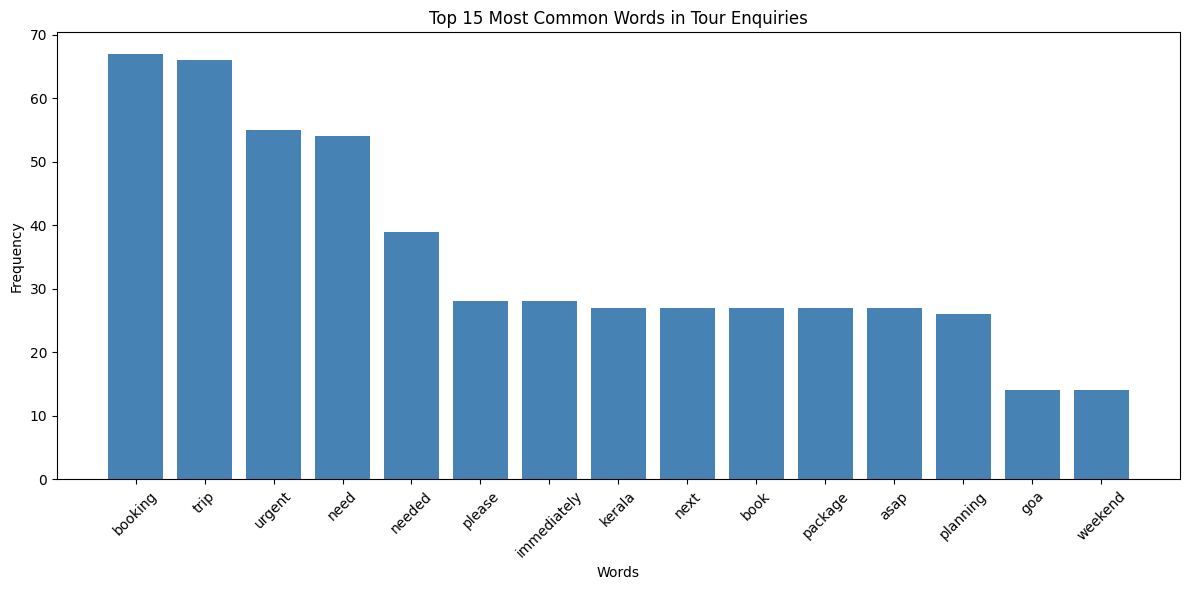

✅ Word Frequency plot saved!


In [6]:
# Step 6: Visualization - Word Frequency
from collections import Counter

all_words = ' '.join(df['cleaned_text']).split()
word_freq = Counter(all_words).most_common(15)

words, freqs = zip(*word_freq)
plt.figure(figsize=(12, 6))
plt.bar(words, freqs, color='steelblue')
plt.title('Top 15 Most Common Words in Tour Enquiries')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('word_frequency.png')
plt.show()
print("✅ Word Frequency plot saved!")

In [7]:
# Step 7: Sample Prediction
def predict_enquiry(text):
    cleaned = preprocess_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = lr_model.predict(vectorized)[0]
    probability = lr_model.predict_proba(vectorized)[0]
    return prediction, probability

# Test karo
test_enquiries = [
    "I need urgent booking for tomorrow's trip!",
    "Planning a relaxing vacation to Goa next month"
]

for enquiry in test_enquiries:
    pred, prob = predict_enquiry(enquiry)
    print(f"Enquiry: {enquiry}")
    print(f"Category: {pred.upper()} (Confidence: {max(prob):.2%})")
    print()

Enquiry: I need urgent booking for tomorrow's trip!
Category: URGENT (Confidence: 86.53%)

Enquiry: Planning a relaxing vacation to Goa next month
Category: NORMAL (Confidence: 82.02%)



In [8]:
# Step 8: Model Save karo
import joblib
joblib.dump(lr_model, 'nlp_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("✅ NLP Model saved!")

✅ NLP Model saved!
